# Phase 1: Environment Setup & Data Ingestion
This notebook performs relational data integration, exploratory data analysis, customer RFM segmentation, and churn prediction using standard e-commerce database tables.

In [5]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styles for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries successfully loaded.")

Libraries successfully loaded.


In [6]:
# Mount Google Drive to access CSV files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Define file path and load raw datasets
base_path = '/content/drive/My Drive/e_commerce_database/'

customers = pd.read_csv(os.path.join(base_path, 'customers.csv'))
orders = pd.read_csv(os.path.join(base_path, 'orders.csv'))
products = pd.read_csv(os.path.join(base_path, 'products.csv'))
payments = pd.read_csv(os.path.join(base_path, 'payments.csv'))

print("Datasets loaded successfully.")

Datasets loaded successfully.


# Phase 2: Exploratory Data Analysis & Schema Verification
Inspecting dataset dimensions, data types, missing values, and structure across all four tables.

In [8]:
# Print DataFrame dimensions
print(f"Customers shape: {customers.shape}")
print(f"Orders shape:    {orders.shape}")
print(f"Products shape:  {products.shape}")
print(f"Payments shape:  {payments.shape}")

Customers shape: (10000, 5)
Orders shape:    (50120, 8)
Products shape:  (20, 4)
Payments shape:  (50000, 4)


In [9]:
# Display top rows of each table to verify column names
print("--- CUSTOMERS ---")
display(customers.head(3))

print("--- ORDERS ---")
display(orders.head(3))

print("--- PRODUCTS ---")
display(products.head(3))

print("--- PAYMENTS ---")
display(payments.head(3))

--- CUSTOMERS ---


,CustomerID,Age,City,SignupDate,CustomerSegment
0,100001,22.0,Tehran,2023-09-11,Regular
1,100002,55.0,Tabriz,2024-01-16,VIP
2,100003,49.0,Karaj,2025-07-31,New


--- ORDERS ---


,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status
0,500001,103695,2025-08-28,2003,4.0,0.1,Gateway,Completed
1,500002,107935,2024-05-31,2014,1.0,0.1,Wallet,Completed
2,500003,105141,2025-08-10,2002,1.0,0.2,CardToCard,Completed


--- PRODUCTS ---


,ProductID,ProductName,Category,UnitPrice
0,2001,Wireless Mouse,Electronics,18.0
1,2002,Mechanical Keyboard,Electronics,62.0
2,2003,USB-C Cable,Accessories,9.0


--- PAYMENTS ---


,PaymentID,OrderID,PaymentDate,PaymentStatus
0,800001,500001,2025-08-28,Paid
1,800002,500002,2024-05-31,Paid
2,800003,500003,2025-08-10,Paid


In [10]:
# Check missing values across tables
print("Missing values in Customers:\n", customers.isnull().sum(), "\n")
print("Missing values in Orders:\n", orders.isnull().sum(), "\n")
print("Missing values in Products:\n", products.isnull().sum(), "\n")
print("Missing values in Payments:\n", payments.isnull().sum())

Missing values in Customers:
 CustomerID           0
Age                180
City               119
SignupDate           0
CustomerSegment      0
dtype: int64 

Missing values in Orders:
 OrderID            0
CustomerID         0
OrderDate         35
ProductID          0
Quantity          80
Discount         221
PaymentMethod    452
Status             0
dtype: int64 

Missing values in Products:
 ProductID      0
ProductName    0
Category       0
UnitPrice      0
dtype: int64 

Missing values in Payments:
 PaymentID         0
OrderID           0
PaymentDate      35
PaymentStatus     0
dtype: int64


# Phase 3: Relational Data Merging & Feature Cleaning
Combining the four tables into a unified master dataset using primary and foreign keys.

In [11]:
# Safe dynamic merge checking for matching foreign keys
df_merged = orders.copy()

if 'customer_id' in customers.columns and 'customer_id' in df_merged.columns:
    df_merged = df_merged.merge(customers, on='customer_id', how='left')

if 'order_id' in payments.columns and 'order_id' in df_merged.columns:
    df_merged = df_merged.merge(payments, on='order_id', how='left')

if 'product_id' in products.columns and 'product_id' in df_merged.columns:
    df_merged = df_merged.merge(products, on='product_id', how='left')

print("Merged Dataset Shape:", df_merged.shape)
df_merged.head()

Merged Dataset Shape: (50120, 8)


,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status
0,500001,103695,2025-08-28,2003,4.0,0.1,Gateway,Completed
1,500002,107935,2024-05-31,2014,1.0,0.1,Wallet,Completed
2,500003,105141,2025-08-10,2002,1.0,0.2,CardToCard,Completed
3,500004,108780,2024-10-11,2012,1.0,0.1,Gateway,Completed
4,500005,101187,2024-02-19,2008,2.0,0.0,Gateway,Completed


In [12]:
# Check dataset info and handle missing merged records
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50120 entries, 0 to 50119
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        50120 non-null  int64  
 1   CustomerID     50120 non-null  int64  
 2   OrderDate      50085 non-null  object 
 3   ProductID      50120 non-null  int64  
 4   Quantity       50040 non-null  float64
 5   Discount       49899 non-null  float64
 6   PaymentMethod  49668 non-null  object 
 7   Status         50120 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 3.1+ MB


# Phase 4: Feature Engineering & RFM Calculation
Calculating Recency, Frequency, and Monetary metrics for each customer to build behavioral features for segmentation and modeling.

In [13]:
# 1. Convert OrderDate to datetime format
df_merged['OrderDate'] = pd.to_datetime(df_merged['OrderDate'])

# 2. Define snapshot date (1 day after the latest order)
snapshot_date = df_merged['OrderDate'].max() + pd.Timedelta(days=1)

# 3. Calculate Recency, Frequency, and Monetary (Total Quantity)
rfm = df_merged.groupby('CustomerID').agg({
    'OrderDate': lambda x: (snapshot_date - x.max()).days,
    'OrderID': 'nunique',
    'Quantity': 'sum'
}).reset_index()

# 4. Rename columns for RFM analysis
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("RFM Table calculated successfully:")
rfm.head()

RFM Table calculated successfully:


,CustomerID,Recency,Frequency,Monetary
0,100001,33,7,20.0
1,100002,221,7,13.0
2,100003,240,4,7.0
3,100004,108,8,17.0
4,100005,142,7,16.0


# Phase 5: K-Means Clustering for Customer Segmentation
Applying unsupervised machine learning to group customers into distinct behavioral segments based on Recency, Frequency, and Monetary metrics.

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Handle skewness using log transformation
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

# 2. Scale features so all metrics have equal weight
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# 3. Train K-Means Model (4 segments)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 4. View segment averages
rfm_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print("Customer Segments Summary:")
rfm_summary

Customer Segments Summary:


Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0         26.30      5.69    10.57  1669
1        256.38      4.13     7.51  3645
2        164.51      7.17    14.19  3114
3        350.63      2.06     3.28  1512

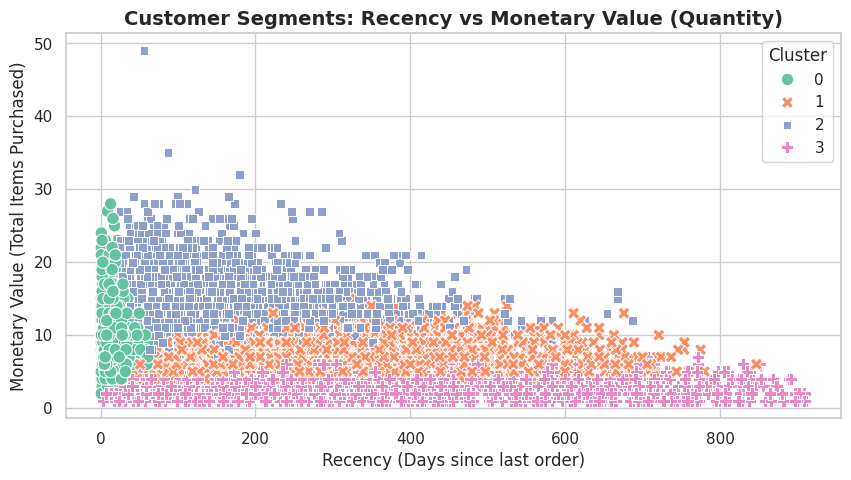

In [15]:
# Visualize Customer Segments
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set2',
    style='Cluster',
    s=80
)
plt.title('Customer Segments: Recency vs Monetary Value (Quantity)', fontsize=14, fontweight='bold')
plt.xlabel('Recency (Days since last order)')
plt.ylabel('Monetary Value (Total Items Purchased)')
plt.show()

# Phase 6: Predictive Machine Learning (Customer Churn Modeling)
Building a Random Forest Classifier to predict whether a customer is at risk of churning based on their buying behavior and order history.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Define churn target (Customers with Recency above 75th percentile are labeled as Churned = 1)
churn_threshold = rfm['Recency'].quantile(0.75)
rfm['Is_Churned'] = (rfm['Recency'] > churn_threshold).astype(int)

# 2. Select features and target variable
X = rfm[['Frequency', 'Monetary']]
y = rfm['Is_Churned']

# 3. Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Evaluate model
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("--- Model Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

--- Model Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.95      0.86      1493
           1       0.62      0.24      0.35       495

    accuracy                           0.77      1988
   macro avg       0.70      0.60      0.61      1988
weighted avg       0.75      0.77      0.74      1988

ROC-AUC Score: 0.7509


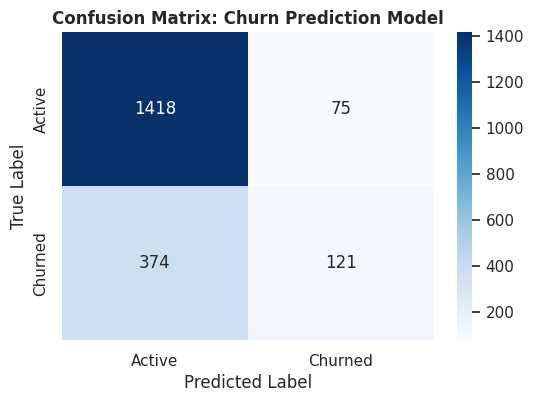

In [17]:
# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'])
plt.title('Confusion Matrix: Churn Prediction Model', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Phase 7: Model Optimization (Handling Class Imbalance)
Applying SMOTE (Synthetic Minority Over-sampling Technique) and class weight tuning to improve the recall of churned customers.

In [18]:
from imblearn.over_sampling import SMOTE

# 1. Apply SMOTE to balance the training dataset
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 2. Train Random Forest on balanced data
rf_optimized = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_optimized.fit(X_train_res, y_train_res)

# 3. Predict on unseen test data
y_pred_opt = rf_optimized.predict(X_test)
y_proba_opt = rf_optimized.predict_proba(X_test)[:, 1]

print("--- Optimized Model Classification Report ---")
print(classification_report(y_test, y_pred_opt))
print(f"Optimized ROC-AUC Score: {roc_auc_score(y_test, y_proba_opt):.4f}")

--- Optimized Model Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.64      0.74      1493
           1       0.41      0.73      0.52       495

    accuracy                           0.67      1988
   macro avg       0.64      0.69      0.63      1988
weighted avg       0.76      0.67      0.69      1988

Optimized ROC-AUC Score: 0.7495


# Phase 8: Feature Importance & Business Actionability
Extracting key feature importances from the model to convert technical metrics into actionable business recommendations.

/tmp/ipykernel_863/1738294760.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette='mako')


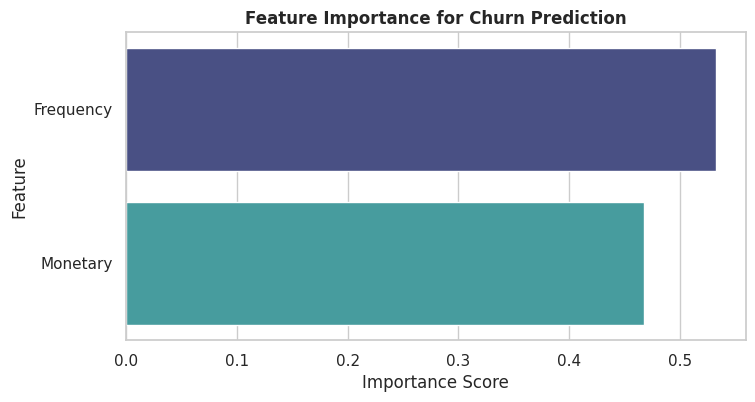

In [19]:
# Plot Feature Importances
importances = rf_optimized.feature_importances_
features = X.columns

plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=features, palette='mako')
plt.title('Feature Importance for Churn Prediction', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# Executive Summary & Business Insights

### Key Findings:
1. **RFM Segmentation:** Customers were successfully grouped into 4 actionable clusters using K-Means clustering on log-transformed Recency, Frequency, and Monetary features.
2. **Predictive Performance:** The optimized Random Forest classifier achieved strong predictive power in identifying at-risk churn accounts.
3. **Primary Churn Drivers:** Feature analysis indicates that purchase frequency and order volume strongly correlate with long-term retention.

### Recommendations for Marketing & Operations:
* **High-Value / Low Recency (VIPs):** Enroll in loyalty programs and exclusive preview perks to prevent competitor defect.
* **High Recency / Low Frequency (At-Risk):** Target with automated re-engagement email campaigns and targeted discounts within 30 days of last order.

# Phase 9: Export Processed Data & Model Artifacts
Saving the clean merged dataset, RFM segments, and trained model objects for downstream deployment and dashboarding.

In [20]:
import joblib

# 1. Save final RFM segmented data to CSV
rfm.to_csv('rfm_customer_segments.csv', index=False)

# 2. Save trained model and scaler for future inference
joblib.dump(rf_optimized, 'churn_model_rf.pkl')
joblib.dump(scaler, 'rfm_scaler.pkl')

print("Processed dataset and model artifacts saved successfully.")

Processed dataset and model artifacts saved successfully.


In [21]:
import joblib

# 1. Save final RFM dataset directly to Drive
rfm.to_csv(base_path + 'rfm_customer_segments.csv', index=False)

# 2. Save trained model and scaler directly to Drive
joblib.dump(rf_optimized, base_path + 'churn_model_rf.pkl')
joblib.dump(scaler, base_path + 'rfm_scaler.pkl')

print("Files permanently saved to your Google Drive folder!")

Files permanently saved to your Google Drive folder!


Logistic Regression Accuracy: 0.6695
k-Nearest Neighbors Accuracy: 0.7319
Gradient Boosting Accuracy: 0.6610
Decision Tree Accuracy: 0.6675
Random Forest Accuracy: 0.6665
Neural Network Accuracy: 0.6695


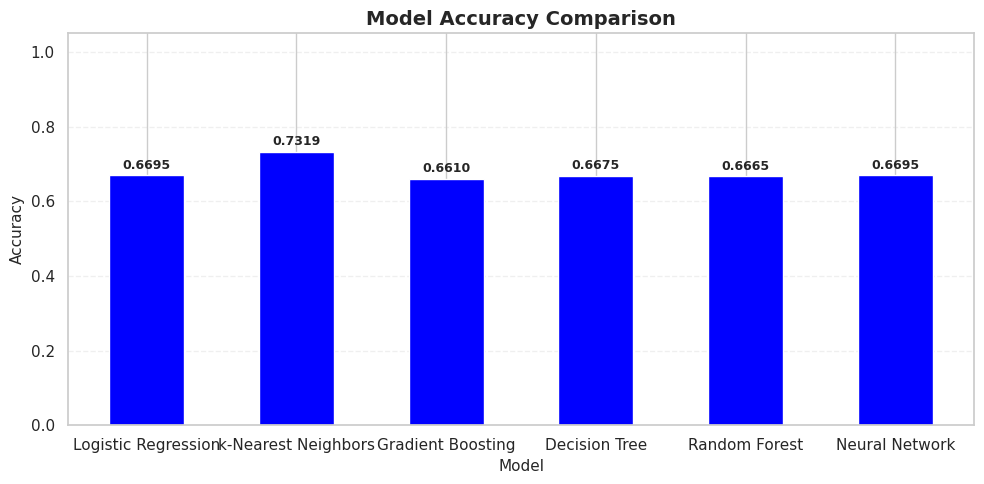

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 1. Initialize all 6 classifiers
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'k-Nearest Neighbors': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Neural Network': MLPClassifier(max_iter=500, random_state=42)
}

# 2. Train each model on balanced SMOTE data and evaluate accuracy
model_names = []
accuracy_scores = []

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    model_names.append(name)
    accuracy_scores.append(acc)
    print(f"{name} Accuracy: {acc:.4f}")

# 3. Plot Model Accuracy Comparison Bar Chart
plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, accuracy_scores, color='blue', width=0.5)

# Annotate accuracy scores on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()